# Day 7: Exploratory Data Analysis
Validate synthetic data realism before building the matcher.
Questions to answer:
1. Are skill distributions realistic?
2. Is availability spread healthy?
3. Can projects actually be staffed from this employee pool?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

plt.style.use("seaborn-v0_8-darkgrid")
FIGSIZE = (12, 5)

emp_df  = pd.read_csv("../data/processed/employees.csv")
proj_df = pd.read_csv("../data/processed/projects.csv")

print(f"Employees : {len(emp_df)} rows × {len(emp_df.columns)} cols")
print(f"Projects  : {len(proj_df)} rows × {len(proj_df.columns)} cols")
print("\n── Sample employees ──")
print(emp_df.head(3).to_string())
print("\n── Sample projects ──")
print(proj_df.head(2).to_string())

Employees : 80 rows × 10 cols
Projects  : 30 rows × 9 cols

── Sample employees ──
  employee_id           name            role  experience_years                                                          skills                                                               proficiency  availability_pct cost_band   department   location
0        E001  Aryan Maharaj    Frontend Dev                 1         JavaScript;React;TypeScript;CSS;GraphQL;Git;Agile/Scrum  Intermediate;Expert;Intermediate;Intermediate;Beginner;Beginner;Beginner                60         B    Analytics  Bangalore
1        E002    Udant Dewan  Full Stack Dev                10  JavaScript;React;Node.js;PostgreSQL;GraphQL;Docker;Agile/Scrum              Expert;Expert;Expert;Expert;Intermediate;Intermediate;Expert                60         B  Engineering  Hyderabad
2        E003     Gagan Sami     Backend Dev                 6                  Python;REST APIs;PostgreSQL;Docker;GraphQL;Git                     Expert;Expe

## 1. Role Distribution

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# Employee roles
role_counts = emp_df["role"].value_counts()
role_counts.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Employees by Role")
axes[0].set_xlabel("Count")

# Cost band
cost_counts = emp_df["cost_band"].value_counts()
cost_counts.plot(kind="bar", ax=axes[1],
                 color=["#2ecc71", "#f39c12", "#e74c3c"])
axes[1].set_title("Employees by Cost Band (A=Junior, C=Senior)")
axes[1].set_xlabel("Band"); axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.savefig("../data/processed/eda_role_cost.png", dpi=150)
plt.show()

## 2. Availability Distribution

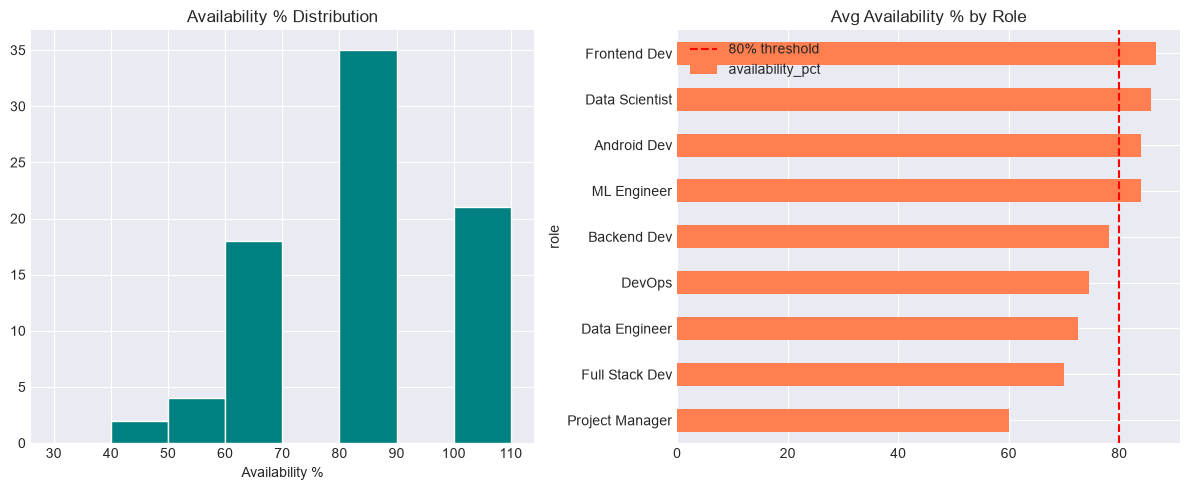

Employees >= 80% available: 56 / 80


In [3]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

emp_df["availability_pct"].hist(
    bins=[30,40,50,60,70,80,90,100,110],
    ax=axes[0], color="teal", edgecolor="white"
)
axes[0].set_title("Availability % Distribution")
axes[0].set_xlabel("Availability %")

# By role
avail_by_role = emp_df.groupby("role")["availability_pct"].mean().sort_values()
avail_by_role.plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title("Avg Availability % by Role")
axes[1].axvline(x=80, color="red", linestyle="--", label="80% threshold")
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/processed/eda_availability.png", dpi=150)
plt.show()

print(f"Employees >= 80% available: "
      f"{(emp_df['availability_pct'] >= 80).sum()} / {len(emp_df)}")

## 3. Skill Frequency Analysis

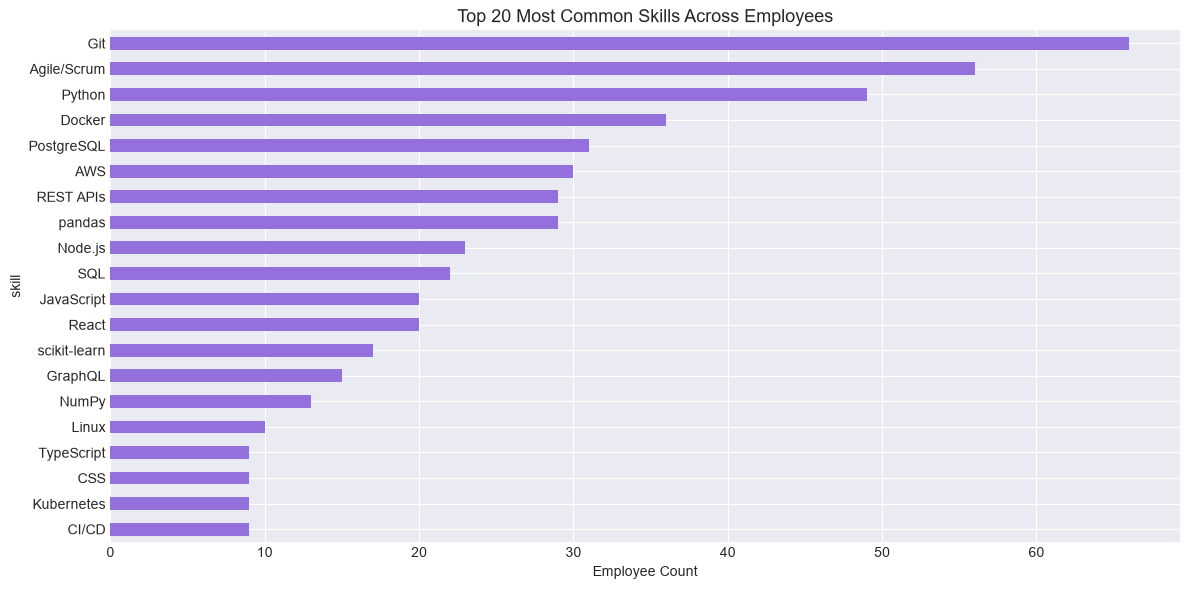

In [4]:
# Flatten all employee skills into a single list
all_skills = []
for skills_str in emp_df["skills"]:
    all_skills.extend([s.strip() for s in skills_str.split(";")])

skill_counts = Counter(all_skills)
skill_df = pd.DataFrame(skill_counts.most_common(20),
                        columns=["skill", "count"])

fig, ax = plt.subplots(figsize=(12, 6))
skill_df.plot(kind="barh", x="skill", y="count", ax=ax,
              color="mediumpurple", legend=False)
ax.set_title("Top 20 Most Common Skills Across Employees", fontsize=13)
ax.set_xlabel("Employee Count")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../data/processed/eda_top_skills.png", dpi=150)
plt.show()

## 4. Proficiency Level Distribution

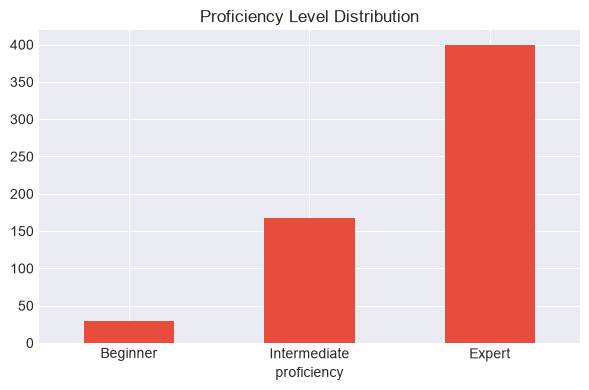

In [5]:
all_profs = []
for prof_str in emp_df["proficiency"]:
    all_profs.extend([p.strip() for p in prof_str.split(";")])

prof_counts = Counter(all_profs)
prof_df = pd.DataFrame(prof_counts.items(),
                       columns=["proficiency","count"])
prof_df = prof_df.set_index("proficiency").loc[
    ["Beginner","Intermediate","Expert"]
]

fig, ax = plt.subplots(figsize=(6, 4))
prof_df.plot(kind="bar", ax=ax, legend=False,
             color=["#e74c3c","#f39c12","#2ecc71"])
ax.set_title("Proficiency Level Distribution")
ax.tick_params(rotation=0)
plt.tight_layout()
plt.savefig("../data/processed/eda_proficiency.png", dpi=150)
plt.show()

## 5. Can Projects Be Staffed? (Feasibility Check)

Roles with ZERO candidates: 0

Candidate pool size distribution:
count    85.0
mean      9.0
std       2.9
min       3.0
25%       7.0
50%       9.0
75%      11.0
max      13.0
Name: candidates_found, dtype: float64


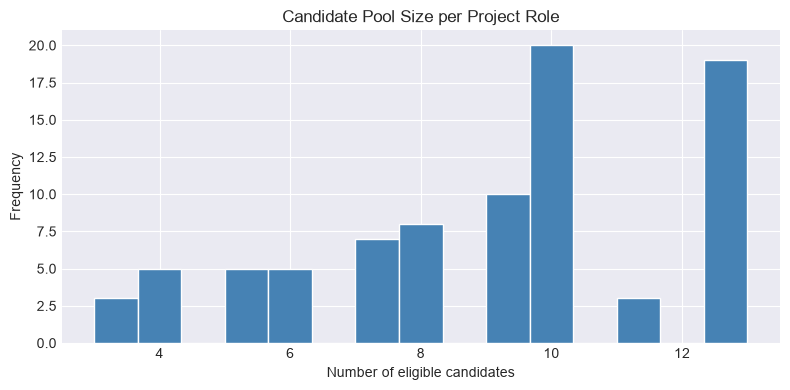

In [6]:
# For each project, count how many employees match required roles
results = []

for _, proj in proj_df.iterrows():
    req_roles   = [r.strip() for r in proj["required_roles"].split(";")]
    req_skills  = [s.strip() for s in proj["required_skills"].split(";")]
    min_exp     = proj["min_experience"]

    for role in req_roles:
        # Employees matching role + experience + availability
        role_match = emp_df[
            (emp_df["role"] == role) &
            (emp_df["experience_years"] >= min_exp) &
            (emp_df["availability_pct"] >= 60)
        ]

        # Further filter by at least 1 required skill match
        skill_match = role_match[
            role_match["skills"].apply(
                lambda s: any(sk in s for sk in req_skills)
            )
        ]

        results.append({
            "project_id":  proj["project_id"],
            "required_role": role,
            "candidates_found": len(skill_match),
            "priority": proj["priority"],
        })

feasibility_df = pd.DataFrame(results)

# Flag roles with zero candidates
zero = feasibility_df[feasibility_df["candidates_found"] == 0]
print(f"Roles with ZERO candidates: {len(zero)}")
if len(zero) > 0:
    print(zero)

# Summary
print("\nCandidate pool size distribution:")
print(feasibility_df["candidates_found"].describe().round(1))

fig, ax = plt.subplots(figsize=(8, 4))
feasibility_df["candidates_found"].hist(bins=15, ax=ax,
                                         color="steelblue",
                                         edgecolor="white")
ax.set_title("Candidate Pool Size per Project Role")
ax.set_xlabel("Number of eligible candidates")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.savefig("../data/processed/eda_feasibility.png", dpi=150)
plt.show()

## 6. Experience Distribution by Role

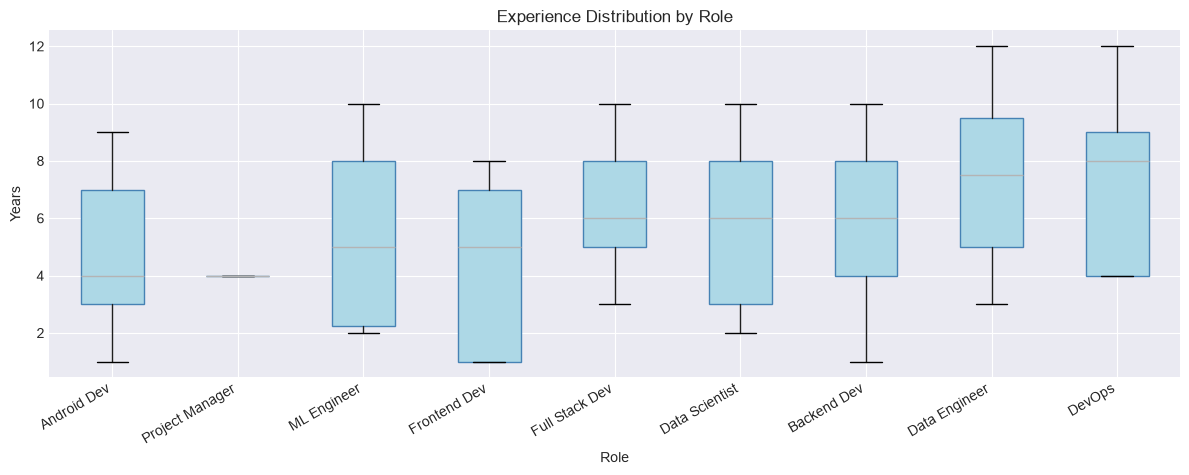

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

roles_sorted = emp_df.groupby("role")["experience_years"].median().sort_values().index
emp_df_sorted = emp_df.copy()
emp_df_sorted["role"] = pd.Categorical(
    emp_df_sorted["role"], categories=roles_sorted, ordered=True
)

emp_df_sorted.boxplot(
    column="experience_years", by="role", ax=ax,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue", color="steelblue"),
)
ax.set_title("Experience Distribution by Role")
ax.set_xlabel("Role"); ax.set_ylabel("Years")
plt.suptitle("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../data/processed/eda_experience.png", dpi=150)
plt.show()

##  Day 7 EDA — Sprint Retro

**Data looks realistic:**
- Skill distributions follow role logic (Python dominant in backend/data)
- Availability spread ensures some scarcity — good for optimizer to solve
- All project roles have at least 1+ eligible candidates

**Sprint 1 Goal: ACHIEVED**
> A believable synthetic dataset we trust enough to build on.

**Next Sprint (Week 2):** Embeddings + semantic matching engine